In [1]:
import umap 
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

from sklearn.manifold import trustworthiness, TSNE
from metrics import pairwise_distance_correlation, knn_accuracy, knn_recall
from sklearn.metrics import silhouette_score

from IsUMap import IsUMap

import time

**Загрузка данных**

In [2]:
adata = sc.read_h5ad('65ca6e36-73b0-4c88-b0f3-7b23b48844ad.h5ad')

In [3]:
print(adata)
print(adata.X.shape)

AnnData object with n_obs × n_vars = 11376 × 60606
    obs: 'donor_id', 'tissue_in_publication', 'anatomical_position', 'method', 'cdna_plate', 'library_plate', 'notes', 'cdna_well', 'assay_ontology_term_id', 'sample_id', 'replicate', '10X_run', 'ambient_removal', 'donor_method', 'donor_assay', 'donor_tissue', 'donor_tissue_assay', 'cell_type_ontology_term_id', 'compartment', 'broad_cell_class', 'free_annotation', 'manually_annotated', 'published_2022', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ercc', 'pct_counts_ercc', '_scvi_batch', '_scvi_labels', 'scvi_leiden_donorassay_full', 'ethnicity_original', 'scvi_leiden_res05_tissue', 'sample_number', 'suspension_type', 'tissue_type', 'disease_ontology_term_id', 'is_primary_data', 'tissue_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'developm

In [4]:
adata.obs

,donor_id,tissue_in_publication,anatomical_position,method,cdna_plate,library_plate,notes,cdna_well,assay_ontology_term_id,sample_id,...,self_reported_ethnicity_ontology_term_id,development_stage_ontology_term_id,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
TSP2_Kidney_cortex_SS2_B113466_B133331_ImmuneEndothelial_E18,TSP2,Kidney,Cortex,smartseq,B113466,B133331,ImmuneEndothelial,E18,EFO:0008931,TSP2_Kidney_Cortex_SS2_B113466_B133331_ImmuneE...,...,unknown,HsapDv:0000155,kidney epithelial cell,Smart-seq2,normal,female,cortex of kidney,unknown,61-year-old stage,GFbQ2g%UpA
TSP2_Kidney_cortex_SS2_B113466_B133331_ImmuneEndothelial_P10,TSP2,Kidney,Cortex,smartseq,B113466,B133331,ImmuneEndothelial,P10,EFO:0008931,TSP2_Kidney_Cortex_SS2_B113466_B133331_ImmuneE...,...,unknown,HsapDv:0000155,B cell,Smart-seq2,normal,female,cortex of kidney,unknown,61-year-old stage,DngVXSU0v$
TSP2_Kidney_cortex_SS2_B113466_B133331_ImmuneEndothelial_O4,TSP2,Kidney,Cortex,smartseq,B113466,B133331,ImmuneEndothelial,O4,EFO:0008931,TSP2_Kidney_Cortex_SS2_B113466_B133331_ImmuneE...,...,unknown,HsapDv:0000155,"CD8-positive, alpha-beta T cell",Smart-seq2,normal,female,cortex of kidney,unknown,61-year-old stage,Lc<tprmCv^
TSP2_Kidney_cortex_SS2_B113466_B133331_ImmuneEndothelial_L17,TSP2,Kidney,Cortex,smartseq,B113466,B133331,ImmuneEndothelial,L17,EFO:0008931,TSP2_Kidney_Cortex_SS2_B113466_B133331_ImmuneE...,...,unknown,HsapDv:0000155,natural killer cell,Smart-seq2,normal,female,cortex of kidney,unknown,61-year-old stage,S+rH&`@oNk
TSP2_Kidney_cortex_SS2_B113466_B133331_ImmuneEndothelial_L23,TSP2,Kidney,Cortex,smartseq,B113466,B133331,ImmuneEndothelial,L23,EFO:0008931,TSP2_Kidney_Cortex_SS2_B113466_B133331_ImmuneE...,...,unknown,HsapDv:0000155,"CD4-positive, alpha-beta T cell",Smart-seq2,normal,female,cortex of kidney,unknown,61-year-old stage,UTloHjBL_^
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TSP2_Kidney_NA_10X_1_1_TTTGTTGGTAACAAGT,TSP2,Kidney,NA,10X,nan,nan,None,nan,EFO:0009922,TSP2_Kidney_NA_10X_1_1,...,unknown,HsapDv:0000155,kidney epithelial cell,10x 3' v3,normal,female,kidney,unknown,61-year-old stage,Zoig>VTpVw
TSP2_Kidney_NA_10X_1_1_TTTGTTGGTCTGCATA,TSP2,Kidney,NA,10X,nan,nan,None,nan,EFO:0009922,TSP2_Kidney_NA_10X_1_1,...,unknown,HsapDv:0000155,"CD8-positive, alpha-beta T cell",10x 3' v3,normal,female,kidney,unknown,61-year-old stage,8(?#P7a8z`
TSP2_Kidney_NA_10X_1_1_TTTGTTGTCAAGAATG,TSP2,Kidney,NA,10X,nan,nan,None,nan,EFO:0009922,TSP2_Kidney_NA_10X_1_1,...,unknown,HsapDv:0000155,kidney epithelial cell,10x 3' v3,normal,female,kidney,unknown,61-year-old stage,X6<0>kgV)`
TSP2_Kidney_NA_10X_1_1_TTTGTTGTCAGGAACG,TSP2,Kidney,NA,10X,nan,nan,None,nan,EFO:0009922,TSP2_Kidney_NA_10X_1_1,...,unknown,HsapDv:0000155,kidney epithelial cell,10x 3' v3,normal,female,kidney,unknown,61-year-old stage,<BYO|X{dBg


In [5]:
adata.var

,ensembl_id,genome,mt,ercc,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,mean,std,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type
ENSG00000000003,ENSG00000000003.15,Gencode_v41,False,False,161872,2.379617,91.800375,4697694.0,0.128648,0.341348,False,TSPAN6,NCBITaxon:9606,gene,2396,protein_coding
ENSG00000000005,ENSG00000000005.6,Gencode_v41,False,False,9323,0.220273,99.527743,434850.0,0.029908,0.194986,False,TNMD,NCBITaxon:9606,gene,873,protein_coding
ENSG00000000419,ENSG00000000419.14,Gencode_v41,False,False,461590,3.523875,76.618161,6956619.0,0.239657,0.436747,False,DPM1,NCBITaxon:9606,gene,1262,protein_coding
ENSG00000000457,ENSG00000000457.14,Gencode_v41,False,False,156149,0.493041,92.090273,973332.0,0.070221,0.253211,False,SCYL3,NCBITaxon:9606,gene,2916,protein_coding
ENSG00000000460,ENSG00000000460.17,Gencode_v41,False,False,120250,0.281519,93.908737,555757.0,0.036778,0.196986,False,FIRRM,NCBITaxon:9606,gene,2661,protein_coding
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000290162,ENSG00000290162.1,Gencode_v41,False,False,600,0.001394,99.969607,2751.0,0.000057,0.003704,False,ENSG00000290162,NCBITaxon:9606,gene,149,unprocessed_pseudogene
ENSG00000290163,ENSG00000290163.1,Gencode_v41,False,False,1814,0.006923,99.908112,13667.0,0.000347,0.018647,False,ENSG00000290163,NCBITaxon:9606,gene,144,unprocessed_pseudogene
ENSG00000290164,ENSG00000290164.1,Gencode_v41,False,False,934,0.005787,99.952688,11424.0,0.000208,0.015328,False,ENSG00000290164,NCBITaxon:9606,gene,138,unprocessed_pseudogene
ENSG00000290165,ENSG00000290165.1,Gencode_v41,False,False,4283,0.014494,99.783045,28613.0,0.000522,0.023898,False,ENSG00000290165,NCBITaxon:9606,gene,144,unprocessed_pseudogene


In [6]:
X = adata.obsm['X_pca'][:, :50].astype(np.float32)
labels = adata.obs['cell_type'].astype(str).to_numpy()

In [7]:
n_neighbors_list = [10, 30, 50, 100]
n_runs = 5
seeds = [42 + i for i in range(n_runs)]


**Применение UMAP**

In [8]:
X_umap_list = []
umap_times = []
for el in n_neighbors_list:
    X_umap_runs = []
    umap_time_runs = []
    for seed in seeds:
        start = time.perf_counter()
        reducer = umap.UMAP(
            n_neighbors=el,
            metric='euclidean',
            random_state=seed,
        )
        X_umap = reducer.fit_transform(X)
        end = time.perf_counter()

        umap_time_runs.append(end - start)
        X_umap_runs.append(X_umap)

    umap_times.append(umap_time_runs)
    X_umap_list.append(X_umap_runs)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no 

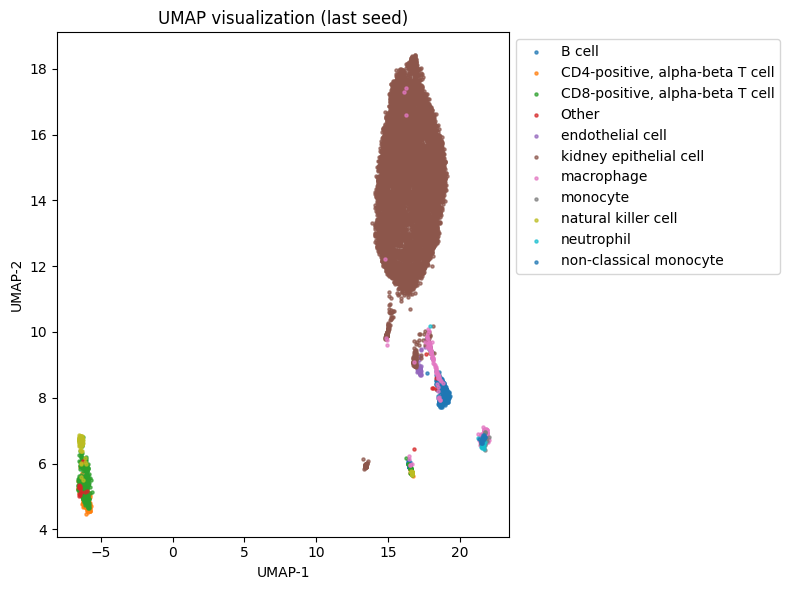

In [23]:
plt.figure(figsize=(8,6))
uniq, cnt = np.unique(labels, return_counts=True)
top = set(uniq[np.argsort(-cnt)[:10]])
labels2 = np.array([l if l in top else 'Other' for l in labels], dtype=object)

for lab in np.unique(labels2):
    m = (labels2 == lab)
    plt.scatter(X_umap_list[-1][-1][m,0], X_umap_list[-1][-1][m,1], s=5, alpha=0.7, label=lab)

plt.title('UMAP visualization (last seed)')
plt.xlabel('UMAP-1'); plt.ylabel('UMAP-2')
plt.legend(bbox_to_anchor=(1,1), loc='upper left')
plt.tight_layout()
plt.show()


**Применение IsUMap**

In [10]:
X_isumap_list = []
isumap_times = []
for el in n_neighbors_list:
    X_isumap_runs = []
    isumap_time_runs = []
    for seed in seeds:
        start = time.perf_counter()
        isumap = IsUMap(
            n_neighbors=el,
            n_components=2,
            metric='euclidean',
            mode='um',
            use_rho=True,
            random_state=seed,
        )
        X_isumap = isumap.fit_transform(X)
        end = time.perf_counter()

        isumap_time_runs.append(end - start)
        X_isumap_runs.append(X_isumap)

    isumap_times.append(isumap_time_runs)
    X_isumap_list.append(X_isumap_runs)


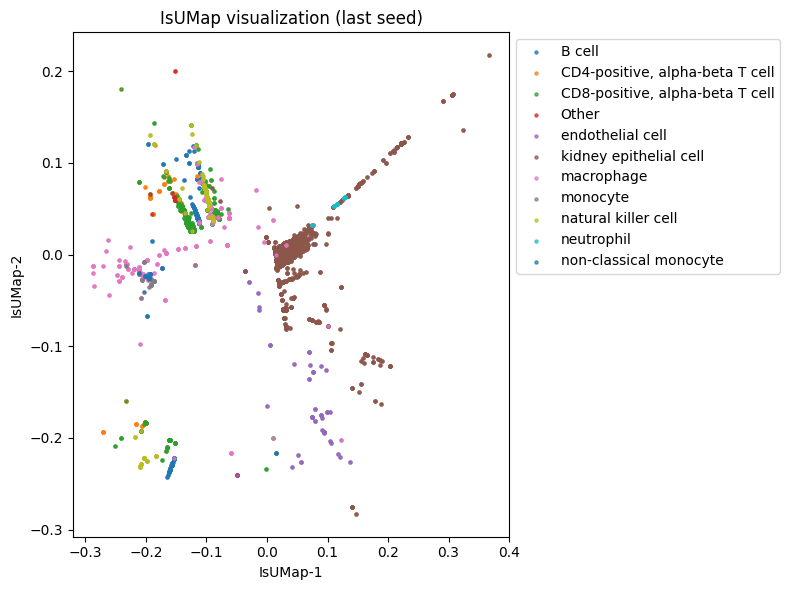

In [22]:
plt.figure(figsize=(8,6))
uniq, cnt = np.unique(labels, return_counts=True)
top = set(uniq[np.argsort(-cnt)[:10]])
labels2 = np.array([l if l in top else 'Other' for l in labels], dtype=object)

for lab in np.unique(labels2):
    m = (labels2 == lab)
    plt.scatter(X_isumap_list[-1][-1][m,0], X_isumap_list[-1][-1][m,1], s=5, alpha=0.7, label=lab)

plt.title('IsUMap visualization (last seed)')
plt.xlabel('IsUMap-1'); plt.ylabel('IsUMap-2')
plt.legend(bbox_to_anchor=(1,1), loc='upper left')
plt.tight_layout()
plt.show()


**Сравнение**

In [12]:
# Time
for i in range(len(n_neighbors_list)):
    print(f'n_neighbors = {n_neighbors_list[i]}')
    print(f'UMAP time: {np.mean(umap_times[i]):.6f} +- {np.std(umap_times[i]):.6f}')
    print(f'IsUMap time: {np.mean(isumap_times[i]):.6f} +- {np.std(isumap_times[i]):.6f}')
    print()


n_neighbors = 10
UMAP time: 5.218309 +- 2.344688
IsUMap time: 174.750544 +- 0.952515

n_neighbors = 30
UMAP time: 10.374643 +- 0.146389
IsUMap time: 381.248820 +- 2.522910

n_neighbors = 50
UMAP time: 16.443902 +- 0.021817
IsUMap time: 602.768688 +- 0.922056

n_neighbors = 100
UMAP time: 32.360254 +- 0.082938
IsUMap time: 1174.583626 +- 0.732695



In [13]:
# Trustworthiness
for i in range(len(n_neighbors_list)):
    print(f'n_neighbors = {n_neighbors_list[i]}')
    tw_umap_runs = [trustworthiness(X, emb, n_neighbors=10, metric='euclidean') for emb in X_umap_list[i]]
    tw_isumap_runs = [trustworthiness(X, emb, n_neighbors=10, metric='euclidean') for emb in X_isumap_list[i]]

    print(f'UMAP trustworthiness: {np.mean(tw_umap_runs):.6f} +- {np.std(tw_umap_runs):.6f}')
    print(f'IsUMap trustworthiness: {np.mean(tw_isumap_runs):.6f} +- {np.std(tw_isumap_runs):.6f}')
    print()


n_neighbors = 10
UMAP trustworthiness: 0.928949 +- 0.000877
IsUMap trustworthiness: 0.872210 +- 0.000000

n_neighbors = 30
UMAP trustworthiness: 0.925511 +- 0.000428
IsUMap trustworthiness: 0.874843 +- 0.000000

n_neighbors = 50
UMAP trustworthiness: 0.923797 +- 0.000329
IsUMap trustworthiness: 0.870979 +- 0.000000

n_neighbors = 100
UMAP trustworthiness: 0.921190 +- 0.000282
IsUMap trustworthiness: 0.872388 +- 0.000000



In [14]:
# pairwise_distance_correlation
for i in range(len(n_neighbors_list)):
    print(f'n_neighbors = {n_neighbors_list[i]}')
    sp_corr_umap_runs = [pairwise_distance_correlation(X, emb, method='spearman')[0] for emb in X_umap_list[i]]
    sp_corr_isumap_runs = [pairwise_distance_correlation(X, emb, method='spearman')[0] for emb in X_isumap_list[i]]

    print(f'UMAP spearman corr: {np.mean(sp_corr_umap_runs):.6f} +- {np.std(sp_corr_umap_runs):.6f}')
    print(f'IsUMap spearman corr: {np.mean(sp_corr_isumap_runs):.6f} +- {np.std(sp_corr_isumap_runs):.6f}')
    print()


n_neighbors = 10
UMAP spearman corr: 0.830847 +- 0.003188
IsUMap spearman corr: 0.773754 +- 0.000000

n_neighbors = 30
UMAP spearman corr: 0.830495 +- 0.002373
IsUMap spearman corr: 0.774161 +- 0.000000

n_neighbors = 50
UMAP spearman corr: 0.842345 +- 0.000526
IsUMap spearman corr: 0.773029 +- 0.000000

n_neighbors = 100
UMAP spearman corr: 0.815629 +- 0.001997
IsUMap spearman corr: 0.772860 +- 0.000000



In [15]:
# knn-accuracy
for i in range(len(n_neighbors_list)):
    print(f'n_neighbors = {n_neighbors_list[i]}')
    acc_umap_runs = [knn_accuracy(emb, labels, n_neighbors=10, cv=5)[0] for emb in X_umap_list[i]]
    acc_isumap_runs = [knn_accuracy(emb, labels, n_neighbors=10, cv=5)[0] for emb in X_isumap_list[i]]

    print(f'UMAP kNN accuracy: {np.mean(acc_umap_runs):.6f} +- {np.std(acc_umap_runs):.6f}')
    print(f'IsUMap kNN accuracy: {np.mean(acc_isumap_runs):.6f} +- {np.std(acc_isumap_runs):.6f}')
    print()


n_neighbors = 10


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packa

UMAP kNN accuracy: 0.975369 +- 0.000659
IsUMap kNN accuracy: 0.958070 +- 0.000000

n_neighbors = 30


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packa

UMAP kNN accuracy: 0.970183 +- 0.001394
IsUMap kNN accuracy: 0.958422 +- 0.000000

n_neighbors = 50


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packa

UMAP kNN accuracy: 0.969269 +- 0.000949
IsUMap kNN accuracy: 0.957630 +- 0.000000

n_neighbors = 100


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packa

UMAP kNN accuracy: 0.962905 +- 0.000674
IsUMap kNN accuracy: 0.954378 +- 0.000000



In [16]:
# knn-recall
for i in range(len(n_neighbors_list)):
    print(f'n_neighbors = {n_neighbors_list[i]}')
    knn_recall_umap_runs = [knn_recall(X, emb) for emb in X_umap_list[i]]
    knn_recall_isumap_runs = [knn_recall(X, emb) for emb in X_isumap_list[i]]

    print(f'UMAP kNN recall: {np.mean(knn_recall_umap_runs):.6f} +- {np.std(knn_recall_umap_runs):.6f}')
    print(f'IsUMap kNN recall: {np.mean(knn_recall_isumap_runs):.6f} +- {np.std(knn_recall_isumap_runs):.6f}')
    print()


n_neighbors = 10
UMAP kNN recall: 0.173743 +- 0.001068
IsUMap kNN recall: 0.217511 +- 0.000000

n_neighbors = 30
UMAP kNN recall: 0.120042 +- 0.002059
IsUMap kNN recall: 0.217985 +- 0.000000

n_neighbors = 50
UMAP kNN recall: 0.099895 +- 0.000594
IsUMap kNN recall: 0.218108 +- 0.000000

n_neighbors = 100
UMAP kNN recall: 0.079524 +- 0.000520
IsUMap kNN recall: 0.218794 +- 0.000000



In [17]:
# silhouette
for i in range(len(n_neighbors_list)):
    print(f'n_neighbors = {n_neighbors_list[i]}')
    silhouette_umap_runs = [silhouette_score(emb, labels) for emb in X_umap_list[i]]
    silhouette_isumap_runs = [silhouette_score(emb, labels) for emb in X_isumap_list[i]]

    print(f'UMAP silhouette: {np.mean(silhouette_umap_runs):.6f} +- {np.std(silhouette_umap_runs):.6f}')
    print(f'IsUMap silhouette: {np.mean(silhouette_isumap_runs):.6f} +- {np.std(silhouette_isumap_runs):.6f}')
    print()


n_neighbors = 10
UMAP silhouette: 0.475198 +- 0.013639
IsUMap silhouette: 0.539695 +- 0.000000

n_neighbors = 30
UMAP silhouette: 0.439140 +- 0.026307
IsUMap silhouette: 0.576086 +- 0.000000

n_neighbors = 50
UMAP silhouette: 0.364786 +- 0.010796
IsUMap silhouette: 0.591685 +- 0.000000

n_neighbors = 100
UMAP silhouette: 0.310707 +- 0.009277
IsUMap silhouette: 0.597219 +- 0.000000



**Применение t-SNE и метрики**

In [ ]:
X_tsne_list = []
tsne_times = []
for el in n_neighbors_list:
    X_tsne_runs = []
    tsne_time_runs = []
    for seed in seeds:
        start = time.perf_counter()
        tsne = TSNE(
            n_components=2,
            perplexity=el,
            metric='euclidean',
            init='pca',
            learning_rate='auto',
            random_state=seed,
        )
        X_tsne = tsne.fit_transform(X)
        end = time.perf_counter()

        tsne_time_runs.append(end - start)
        X_tsne_runs.append(X_tsne)

    tsne_times.append(tsne_time_runs)
    X_tsne_list.append(X_tsne_runs)



In [20]:
for i in range(len(n_neighbors_list)):
    print(f'perplexity = {n_neighbors_list[i]}')
    print(f't-SNE time: {np.mean(tsne_times[i]):.6f} +- {np.std(tsne_times[i]):.6f}')

    tw_tsne_runs = [trustworthiness(X, emb, n_neighbors=10, metric='euclidean') for emb in X_tsne_list[i]]
    print(f't-SNE trustworthiness: {np.mean(tw_tsne_runs):.6f} +- {np.std(tw_tsne_runs):.6f}')

    sp_corr_tsne_runs = [pairwise_distance_correlation(X, emb, method='spearman')[0] for emb in X_tsne_list[i]]
    print(f't-SNE spearman corr: {np.mean(sp_corr_tsne_runs):.6f} +- {np.std(sp_corr_tsne_runs):.6f}')

    acc_tsne_runs = [knn_accuracy(emb, labels, n_neighbors=10, cv=5)[0] for emb in X_tsne_list[i]]
    print(f't-SNE kNN accuracy: {np.mean(acc_tsne_runs):.6f} +- {np.std(acc_tsne_runs):.6f}')

    knn_recall_tsne_runs = [knn_recall(X, emb) for emb in X_tsne_list[i]]
    print(f't-SNE kNN recall: {np.mean(knn_recall_tsne_runs):.6f} +- {np.std(knn_recall_tsne_runs):.6f}')

    silhouette_tsne_runs = [silhouette_score(emb, labels) for emb in X_tsne_list[i]]
    print(f't-SNE silhouette: {np.mean(silhouette_tsne_runs):.6f} +- {np.std(silhouette_tsne_runs):.6f}')
    print()

perplexity = 10
t-SNE time: 12.354502 +- 0.055134
t-SNE trustworthiness: 0.980492 +- 0.000269
t-SNE spearman corr: 0.567780 +- 0.000835


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packa

t-SNE kNN accuracy: 0.975950 +- 0.000189
t-SNE kNN recall: 0.372414 +- 0.000167
t-SNE silhouette: -0.022593 +- 0.005064

perplexity = 30
t-SNE time: 13.333435 +- 0.030191
t-SNE trustworthiness: 0.984061 +- 0.000145
t-SNE spearman corr: 0.651927 +- 0.001101


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packa

t-SNE kNN accuracy: 0.975598 +- 0.000163
t-SNE kNN recall: 0.379604 +- 0.000186
t-SNE silhouette: 0.088891 +- 0.003515

perplexity = 50
t-SNE time: 15.296931 +- 0.036789
t-SNE trustworthiness: 0.984312 +- 0.000163
t-SNE spearman corr: 0.706972 +- 0.001550


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packa

t-SNE kNN accuracy: 0.974578 +- 0.000117
t-SNE kNN recall: 0.369219 +- 0.000444
t-SNE silhouette: 0.108323 +- 0.002710

perplexity = 100
t-SNE time: 20.385670 +- 0.100336
t-SNE trustworthiness: 0.982382 +- 0.000156
t-SNE spearman corr: 0.769159 +- 0.000609


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packa

t-SNE kNN accuracy: 0.974983 +- 0.000163
t-SNE kNN recall: 0.337185 +- 0.000317
t-SNE silhouette: 0.217227 +- 0.003056



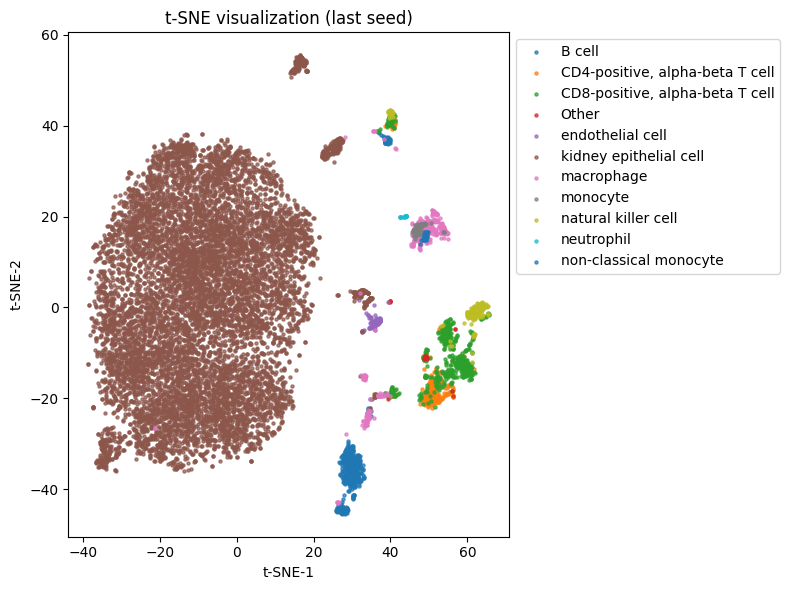

In [21]:
plt.figure(figsize=(8,6))
uniq, cnt = np.unique(labels, return_counts=True)
top = set(uniq[np.argsort(-cnt)[:10]])
labels2 = np.array([l if l in top else 'Other' for l in labels], dtype=object)

for lab in np.unique(labels2):
    m = (labels2 == lab)
    plt.scatter(X_tsne_list[-1][-1][m,0], X_tsne_list[-1][-1][m,1], s=5, alpha=0.7, label=lab)

plt.title('t-SNE visualization (last seed)')
plt.xlabel('t-SNE-1'); plt.ylabel('t-SNE-2')
plt.legend(bbox_to_anchor=(1,1), loc='upper left')
plt.tight_layout()
plt.show()
